## Major Steps

1. **Initial Data Analysis**:
   - Conducted a thorough analysis of the dataset to understand its structure, identify key features, and detect any anomalies or missing values.

2. **Data Segmentation**:
   - Split the dataset into two distinct subsets:
     - **Class A Cities Customers**: Customers residing in major metropolitan areas.
     - **Other Cities Customers**: Customers residing in smaller cities and towns.
   - This segmentation was achieved using KMeans Clustering to ensure accurate classification based on customer location.

3. **Regression and Classification Analysis**:
   - Performed separate regression and classification analyses on both subsets to tailor the models to the specific characteristics of each group.
   - Utilized a variety of regression models, including Linear Regression, SVR, Gradient Boosting Regressor, Random Forest Regressor, Decision Tree Regressor, and KNeighbors Regressor.
   - Employed multiple classification models, such as Logistic Regression, SVC, Random Forest Classifier to identify the best-performing model for each subset.

4. **Model Evaluation and Selection**:
   - Evaluated the performance of each model using key metrics such as Mean Squared Error (MSE), R-squared (R²), accuracy, precision, recall, F1 score, and AUC.
   - Visualized the results with plots to compare the performance of different models and select the best-suited model for each dataset.

5. **Prediction on New Data**:
   - Created a new dataset with Sales prices ranging from 60 to 150.
   - Applied the best-performing models to this new dataset to demonstrate their predictive capabilities separately for Class A cities and other cities customers.

6. **Visualization and Reporting**:
   - Generated comprehensive plots and visualizations to illustrate the performance of the selected models.
   - Documented the entire process and findings in a detailed report to provide clear insights and actionable recommendations.

By following these steps, we ensured a robust and tailored approach to model selection and prediction, catering to the unique characteristics of customers from different city classifications.

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

In [122]:
import warnings
warnings.filterwarnings("ignore")

reading the fitco.csv file 

In [123]:
df = pd.read_csv('fitco.csv')
df.sample(5)

,Sales,SellingPrice,Returned
138,9933.5,115.0,0
338,5810.5,100.5,0
292,4965.5,128.5,0
622,6699.5,69.0,1
629,10408.5,130.5,0


To gain a better understanding of the DataFrame, we will examine its structure, including the data types of each column and other relevant information.

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sales         1000 non-null   float64
 1   SellingPrice  1000 non-null   float64
 2   Returned      1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [125]:
count = df.isnull().sum()
print(f"Missing values in the dataset: ")
print(count)

Missing values in the dataset: 
Sales           0
SellingPrice    0
Returned        0
dtype: int64


In [126]:
df.describe()

,Sales,SellingPrice,Returned
count,1000.000000,1000.000000,1000.000000
mean,7876.227000,110.565500,0.113000
std,1975.587319,25.600749,0.316751
min,4511.500000,50.500000,0.000000
25%,6017.125000,96.000000,0.000000
50%,7642.000000,114.000000,0.000000
75%,9926.750000,132.000000,0.000000
max,10536.000000,150.000000,1.000000


Visualising the dataset for better understanding

<Axes: xlabel='SellingPrice', ylabel='Sales'>

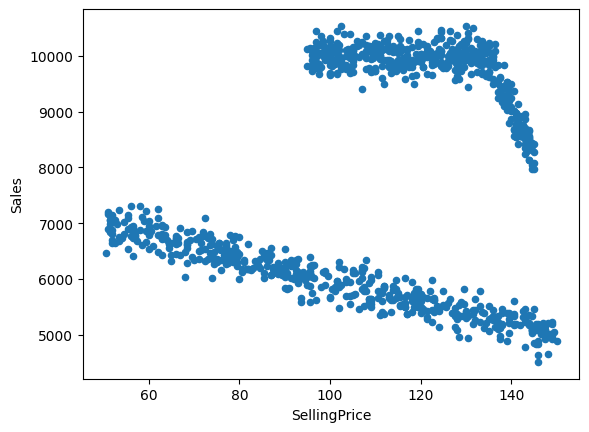

In [127]:
df.plot(kind='scatter', x='SellingPrice', y='Sales')

From this plot, we can clearly observe two distinct trends in the relationship between sales and selling price. It is likely that one cluster represents Class-A cities, while the other corresponds to other cities, as suggested by the Executive.

<Axes: xlabel='SellingPrice', ylabel='Sales'>

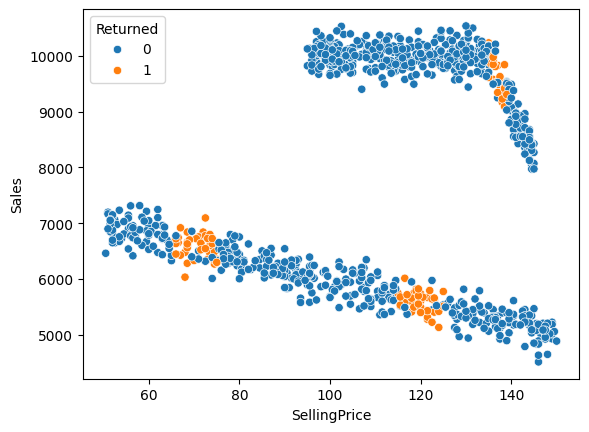

In [128]:
sns.scatterplot(data=df, x='SellingPrice', y='Sales',hue='Returned')

There is clearly a range of selling prices where customers are most likely to return the product.

The first step is to separate the data for Class-A cities from other cities to enable more effective predictions.

To achieve this, we can define an unsupervised clustering model to create two distinct datasets. We can then apply our prediction models to each dataset separately.

First create a separate copy of dataset to work with so that initial dataset is not changed unknowingly

In [129]:
dataset = df.__deepcopy__()


In [130]:
kmeans = KMeans(n_clusters=2,random_state=0)
dataset['cluster'] = kmeans.fit_predict(dataset[['SellingPrice','Sales']])
dataset.sample(5)


,Sales,SellingPrice,Returned,cluster
728,6518.0,76.0,0,1
422,9845.5,125.0,0,0
69,9903.5,116.5,0,0
933,10017.0,96.0,0,0
952,9841.0,138.5,1,0


<Axes: xlabel='SellingPrice', ylabel='Sales'>

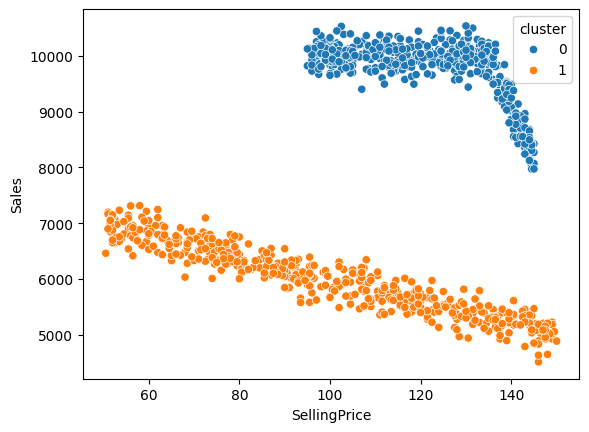

In [131]:
sns.scatterplot(data=dataset, x='SellingPrice', y='Sales',hue='cluster')

As we can see, KMeans has correctly identified the clusters.

The executive discusses the unusual purchasing behavior of customers in Class-A cities.

**Assumption**

From the two clusters, I will assume that cluster 0 represents customers from Class-A cities.

Separating the two dataset into ClassA_Dataset and Other_Dataset 

In [132]:
classA_Dataset = dataset[dataset['cluster'] == 0].drop('cluster',axis=1)
other_Dataset = dataset[dataset['cluster'] == 1].drop('cluster',axis=1)

In [133]:
classA_Dataset.sample(5)

,Sales,SellingPrice,Returned
148,10497.5,131.5,0
334,9806.5,120.5,0
363,8523.5,144.0,0
689,9930.5,112.0,0
376,10295.0,132.5,0


## Class-A Customer Data Prediction

- **Regression Model**: Predict the total sales value of the product given its selling price.
- **Classification Model**: Classify the product based on the likelihood of it being returned.

Once Again Taking a look at the DataSet

<Axes: xlabel='SellingPrice', ylabel='Sales'>

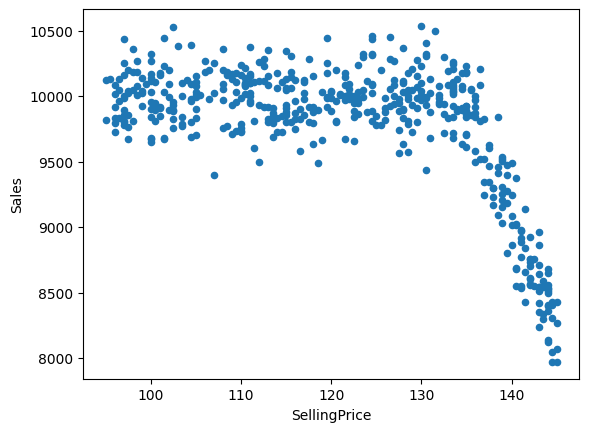

In [134]:
classA_Dataset.plot(kind='scatter', x='SellingPrice', y='Sales')

In [135]:
classA_Dataset.describe()

,Sales,SellingPrice,Returned
count,500.000000,500.000000,500.000000
mean,9765.683000,121.475000,0.060000
std,531.007287,14.916564,0.237725
min,7970.000000,95.000000,0.000000
25%,9703.500000,109.500000,0.000000
50%,9927.000000,122.500000,0.000000
75%,10092.375000,134.625000,0.000000
max,10536.000000,145.000000,1.000000


In [136]:
# Divide the classA_Dataset into train and test sets with an 8:2 ratio
train_set, test_set = train_test_split(classA_Dataset, test_size=0.2, random_state=0)

# Display the size of the train and test sets
print(f"Training set size: {train_set.shape[0]}")
print(f"Test set size: {test_set.shape[0]}")

Training set size: 400
Test set size: 100


### Regression Analysis of Class A cities customers 

- Possible Regression to look at are : 
 - Linear Regression
 - SVR
 - Gradient Boosting Regressor
 - Random Forest Regressor

### Overview of `perform_regression` Function

The `perform_regression` function trains and evaluates multiple regression models on a given dataset. Here's a summary of its key steps:

1. **Data Extraction**:
   - Extracts the feature (`SellingPrice`) and target (`Sales`) columns from the training and test datasets.
   - Stores these columns in `X_train`, `y_train`, `X_test`, and `y_test`.

2. **Model Initialization**:
   - Initializes a dictionary `models` containing several regression models from scikit-learn:
     - `LinearRegression`
     - `SVR`
     - `GradientBoostingRegressor`
     - `RandomForestRegressor`
     - `DecisionTreeRegressor`
     - `KNeighborsRegressor`

3. **Model Training and Evaluation**:
   - Creates an empty dictionary `results` to store evaluation metrics.
   - Sets up a Matplotlib figure for visualizing actual vs. predicted values.
   - Iterates over each model:
     - Trains the model on `X_train` and `y_train`.
     - Makes predictions on `X_test`.
     - Evaluates performance using Mean Squared Error (MSE) and R-squared (R²) score.
     - Stores metrics and the trained model in the `results` dictionary.

4. **Visualization**:
   - Creates subplots for each model, displaying scatter plots of actual (blue) vs. predicted (red) values.
   - Titles each subplot with the model name, MSE, and R² score.
   - Adjusts the layout and displays the figure using `plt.show()`.

5. **Output**:
   - Returns the `results` dictionary containing evaluation metrics and trained models.

This approach allows for easy comparison of different regression models on the same dataset.

In [137]:
def perform_regression(train_set, test_set):
    X_train = train_set[['SellingPrice']]
    y_train = train_set['Sales']
    X_test = test_set[['SellingPrice']]
    y_test = test_set['Sales']
    
    models = {
        'Linear Regression': LinearRegression(),
        'SVR': SVR(),
        'Gradient Boosting Regressor': GradientBoostingRegressor(),
        'Random Forest Regressor': RandomForestRegressor(),
        'Decision Tree Regressor': DecisionTreeRegressor(),
        'KNeighbors Regressor': KNeighborsRegressor()
    }
    
    results = {}
    plt.figure(figsize=(18, 12))
    
    for i, (name, model) in enumerate(models.items(), 1):
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        mse = mean_squared_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)
        results[name] = {'MSE': mse, 'R2': r2,'model':model}
        
        plt.subplot(3, 3, i)
        plt.scatter(X_test, y_test, color='blue', label='Actual Values')
        plt.scatter(X_test, predictions, color='red', label='Predicted Values', alpha=0.5)
        plt.title(f'{name}\nMSE: {mse:.2f}, R2: {r2:.2f}')
        plt.xlabel('Selling Price')
        plt.ylabel('Sales')
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return results

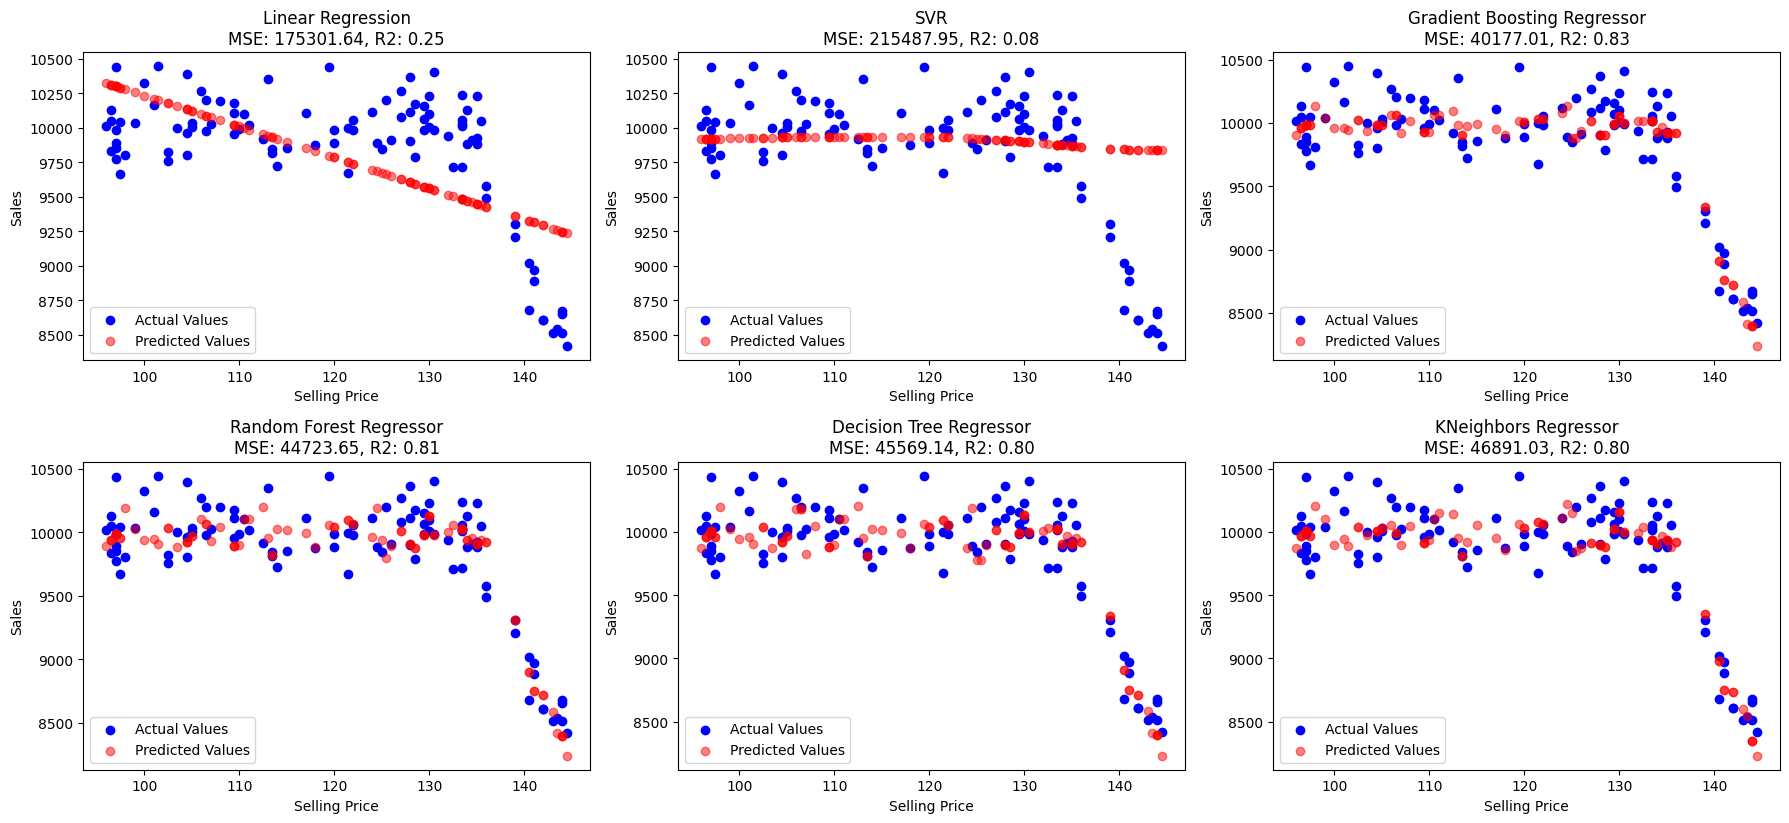

Linear Regression:
MSE: 175301.64179862247
R2: 0.2496541229023186

SVR:
MSE: 215487.95334197447
R2: 0.07764413558596428

Gradient Boosting Regressor:
MSE: 40177.0060355116
R2: 0.8280298431688067

Random Forest Regressor:
MSE: 44723.65403165435
R2: 0.8085687671428379

Decision Tree Regressor:
MSE: 45569.13538948398
R2: 0.8049498423883328

KNeighbors Regressor:
MSE: 46891.033699999985
R2: 0.7992917040100425



In [138]:
regression_results = perform_regression(train_set, test_set)

for model, metrics in regression_results.items():
    print(f"{model}:")
    print(f"MSE: {metrics['MSE']}")
    print(f"R2: {metrics['R2']}")
    print()

### `plot_metrics` Function Overview

The `plot_metrics` function visualizes the performance metrics of different models using Matplotlib. It takes a dictionary called `results` as input, where keys are model names and values are dictionaries containing metrics like Mean Squared Error (MSE) and R-squared (R²).

#### Steps:

1. **Extract Metrics**:
   - Extracts model names into a list `models`.
   - Retrieves MSE and R² values for each model, storing them in `mse_values` and `r2_values`.

2. **Create Subplots**:
   - Initializes a figure and subplots with a size of 14x8 inches using `plt.subplots`.
   - Configures the first subplot (`ax1`) to display MSE values as a bar chart.
     - X-axis labeled "Models" and Y-axis labeled "MSE" (blue).
     - Rotates x-axis labels 45 degrees for readability.

3. **Overlay R² Values**:
   - Creates a second y-axis (`ax2`) sharing the same x-axis as `ax1` using `twinx`.
   - Labels the second y-axis "R²" (red) and plots R² values as a line chart with markers.

4. **Finalize Plot**:
   - Sets the plot title to "Model Performance Metrics".
   - Displays the plot using `plt.show()`.

This dual-axis plot effectively visualizes both MSE and R² metrics, facilitating easy comparison of model performance.

In [139]:
def plot_metrics(results):
    models = list(results.keys())
    mse_values = [results[model]['MSE'] for model in models]
    r2_values = [results[model]['R2'] for model in models]
    
    fig, ax1 = plt.subplots(figsize=(14, 8))

    color = 'tab:blue'
    ax1.set_xlabel('Models')
    ax1.set_ylabel('MSE', color=color)
    ax1.bar(models, mse_values, color=color, alpha=0.6, label='MSE')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticklabels(models, rotation=45, ha='right')

    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('R²', color=color)
    ax2.plot(models, r2_values, color=color, marker='o', linestyle='dashed', linewidth=2, markersize=8, label='R²')
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()
    plt.title('Model Performance Metrics')
    plt.show()

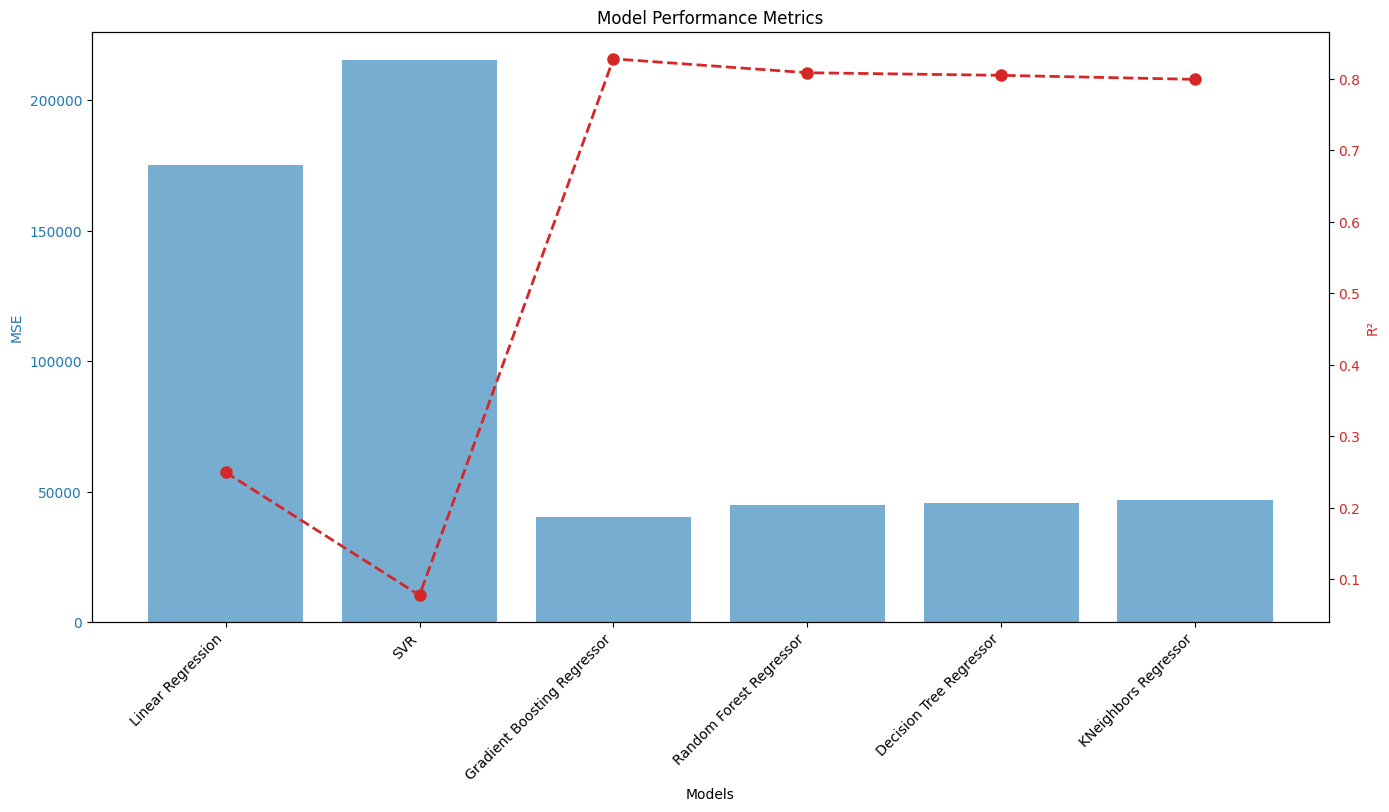

In [140]:
plot_metrics(regression_results)

**Gradient Boosting Regressor Performs Best with highest R2 Score**

Another Close Alternative can be Random Forest Regressor

### Classification Prediction

Classification Models to examine are : 
- Logistic Regression
- SVC
- Random Forest Classifier ( three types with min_leaf_sample as 1,3 and 5)

<Axes: xlabel='SellingPrice', ylabel='Sales'>

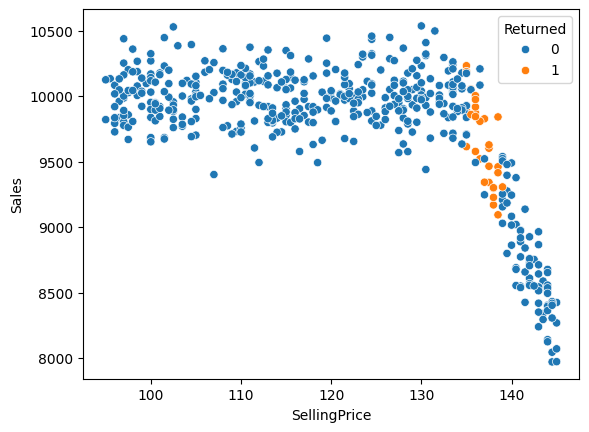

In [141]:
sns.scatterplot(data=classA_Dataset, x='SellingPrice', y='Sales',hue='Returned')

### `evaluate_model` Function Overview

The `evaluate_model` function is designed to assess the performance of a machine learning model by calculating several key metrics. It takes three arguments: `y_test`, `y_predict`, and `y_prob`.

#### Parameters:
- `y_test`: The true labels of the test dataset.
- `y_predict`: The predicted labels generated by the model.
- `y_prob`: The predicted probabilities for the positive class.

#### Function Steps:

1. **Initialize Metrics Dictionary**:
   - A dictionary named `metrics` is initialized to store the calculated performance metrics.

2. **Calculate Accuracy**:
   - `metrics['accuracy'] = accuracy_score(y_test, y_predict)`
   - Accuracy measures the proportion of correctly predicted labels out of the total number of predictions.

3. **Calculate Precision**:
   - `metrics['precision'] = precision_score(y_test, y_predict)`
   - Precision is the ratio of true positive predictions to the total number of positive predictions, indicating the model's ability to avoid false positives.

4. **Calculate Recall**:
   - `metrics['recall'] = recall_score(y_test, y_predict)`
   - Recall is the ratio of true positive predictions to the total number of actual positives, reflecting the model's ability to capture all relevant instances.

5. **Calculate F1 Score**:
   - `metrics['f1'] = f1_score(y_test, y_predict)`
   - The F1 score is the harmonic mean of precision and recall, providing a single metric that balances both concerns.

6. **Calculate AUC-ROC**:
   - `metrics['auc'] = roc_auc_score(y_test, y_prob)`
   - The Area Under the Receiver Operating Characteristic Curve (AUC-ROC) evaluates the model's ability to distinguish between positive and negative classes, with higher values indicating better performance.

7. **Return Metrics**:
   - The function returns the `metrics` dictionary, providing a comprehensive overview of the model's performance.


In [142]:
def evaluate_model(y_test, y_predict, y_prob):
    metrics = {}
    metrics['accuracy'] = accuracy_score(y_test, y_predict)
    
    metrics['precision'] = precision_score(y_test, y_predict)
    metrics['recall'] = recall_score(y_test, y_predict)
    metrics['f1'] = f1_score(y_test, y_predict)
    
    metrics['auc'] = roc_auc_score(y_test, y_prob)
    
    return metrics

In [143]:
def plot_roc(ax, y_true, y_prob, model_name, dataset):
    # Compute ROC curve and ROC area for the binary classification
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')

    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} - {dataset} Data')
    ax.legend(loc="lower right")

### `classification_model` Function Overview

The `classification_model` function trains and evaluates multiple classification models on a given dataset. It takes three parameters: `train_set`, `test_set`, and `models`.

#### Parameters:
- `train_set`: A pandas DataFrame containing the training data.
- `test_set`: A pandas DataFrame containing the testing data.
- `models`: A dictionary where keys are model names and values are model instances.

#### Function Steps:

1. **Data Preparation**:
   - Extracts features (`SellingPrice` and `Sales`) and target variable (`Returned`) from the training and testing datasets.
   - Stores these columns in `X_train`, `y_train`, `X_test`, and `y_test`.

2. **Model Training and Evaluation**:
   - Initializes an empty list `results` to store evaluation metrics.
   - Iterates over each model in the `models` dictionary:
     - Fits the model to the training data (`X_train`, `y_train`).
     - Makes predictions on the training data and calculates probabilities for the positive class.
     - Evaluates the model on the training data using the `evaluate_model` function and appends the metrics to `results`.
     - Makes predictions on the testing data and calculates probabilities for the positive class.
     - Evaluates the model on the testing data using the `evaluate_model` function and appends the metrics to `results`.

3. **Visualization**:
   - For each model, creates a Matplotlib figure with two subplots:
     - Plots the ROC curve for the training data on the first subplot.
     - Plots the ROC curve for the testing data on the second subplot.

4. **Return Results**:
   - Returns the `results` list, which contains the evaluation metrics for each model on both the training and testing datasets.


In [144]:
def classification_model(train_set, test_set, models):
    X_train = train_set[['SellingPrice', 'Sales']]
    y_train = train_set['Returned']
    X_test = test_set[['SellingPrice', 'Sales']]
    y_test = test_set['Returned']
    results = []

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        
        y_train_predict = model.predict(X_train)
        y_train_prob = model.predict_proba(X_train)[:, 1]  # Get probability for the positive class
        metrics_train = evaluate_model(y_train, y_train_predict, y_train_prob)
        results.append({
            'model': model_name,
            'dataset': 'train',
            'fitted_model': model,
            **metrics_train
        })
        
        y_test_predict = model.predict(X_test)
        y_test_prob = model.predict_proba(X_test)[:, 1]  # Get probability for the positive class
        metrics_test = evaluate_model(y_test, y_test_predict, y_test_prob)
        results.append({
            'model': model_name,
            'dataset': 'test',
            **metrics_test
        })
        
        fig, axs = plt.subplots(1, 2, figsize=(18, 6))
        
        plot_roc(axs[0], y_train, y_train_prob, model_name, 'Train')
        plot_roc(axs[1], y_test, y_test_prob, model_name, 'Test')
        
        plt.suptitle(f'{model_name}')
        plt.show()
    return results 
        

In [145]:
models = {
    "Logistic Regression":LogisticRegression(),
    "SVC (linear)" :SVC(kernel='linear',probability=True), 
    "Random Forest Classifier (1)":RandomForestClassifier(min_samples_leaf=1,),
    "Random Forest Classifier (3)":RandomForestClassifier(min_samples_leaf=3),
    "Random Forest Classifier (5)":RandomForestClassifier(min_samples_leaf=5),
}

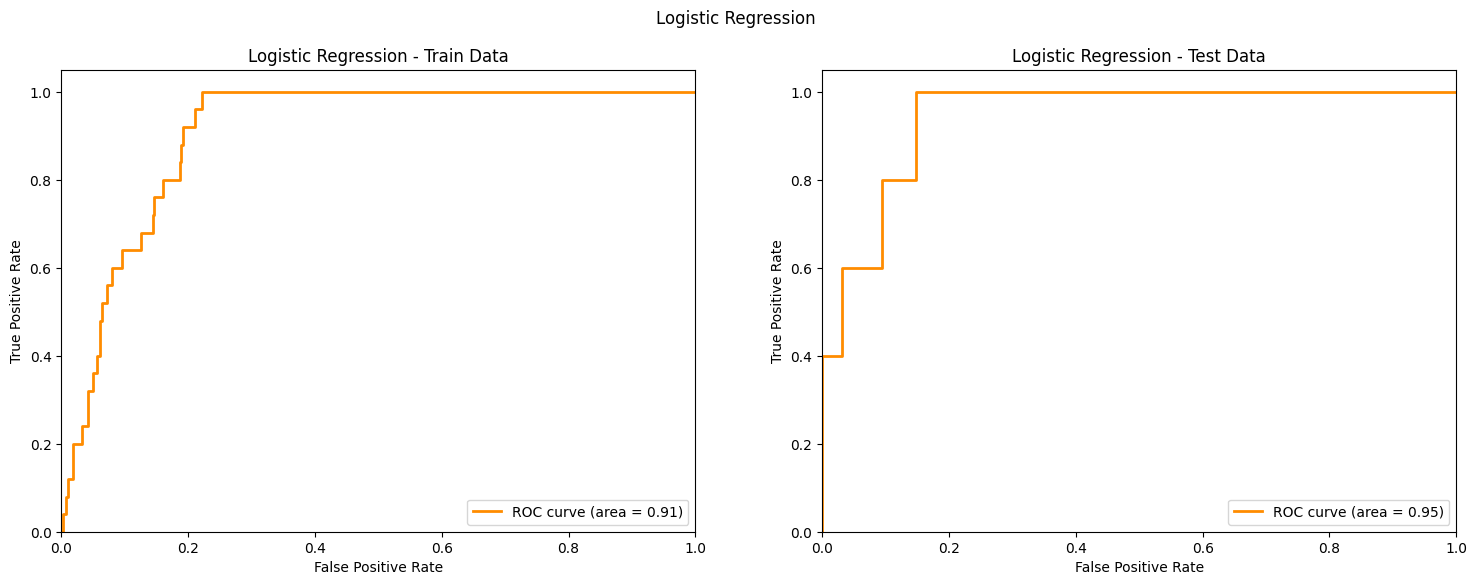

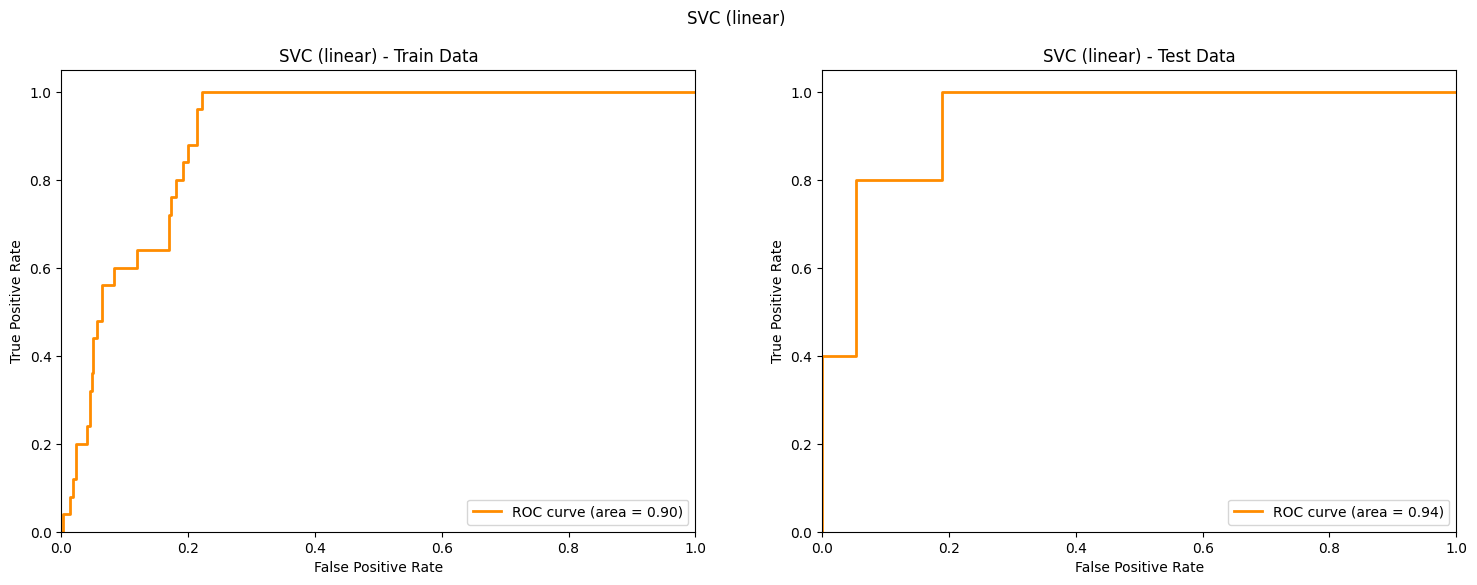

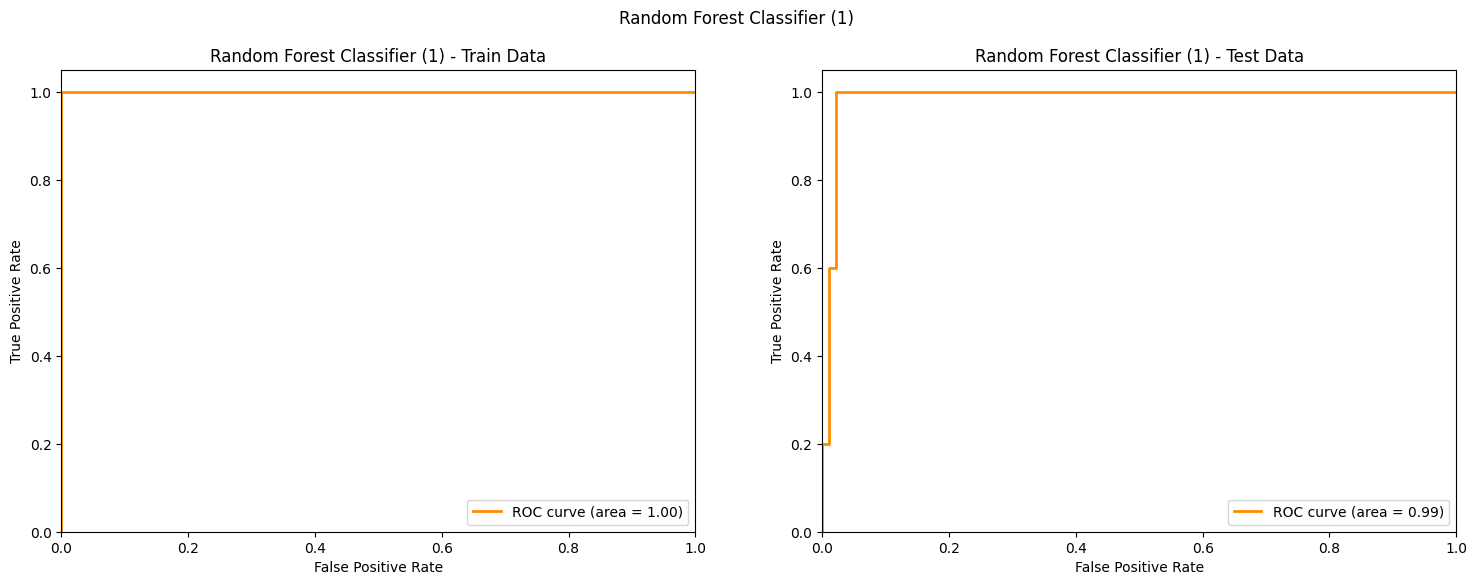

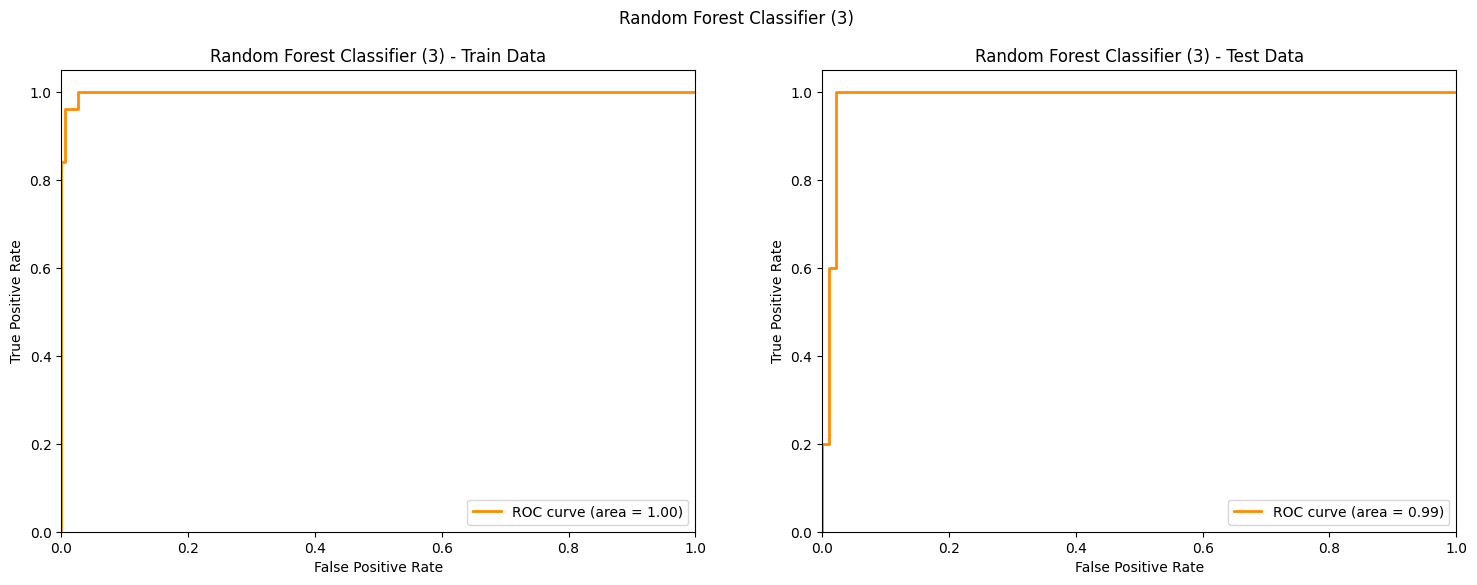

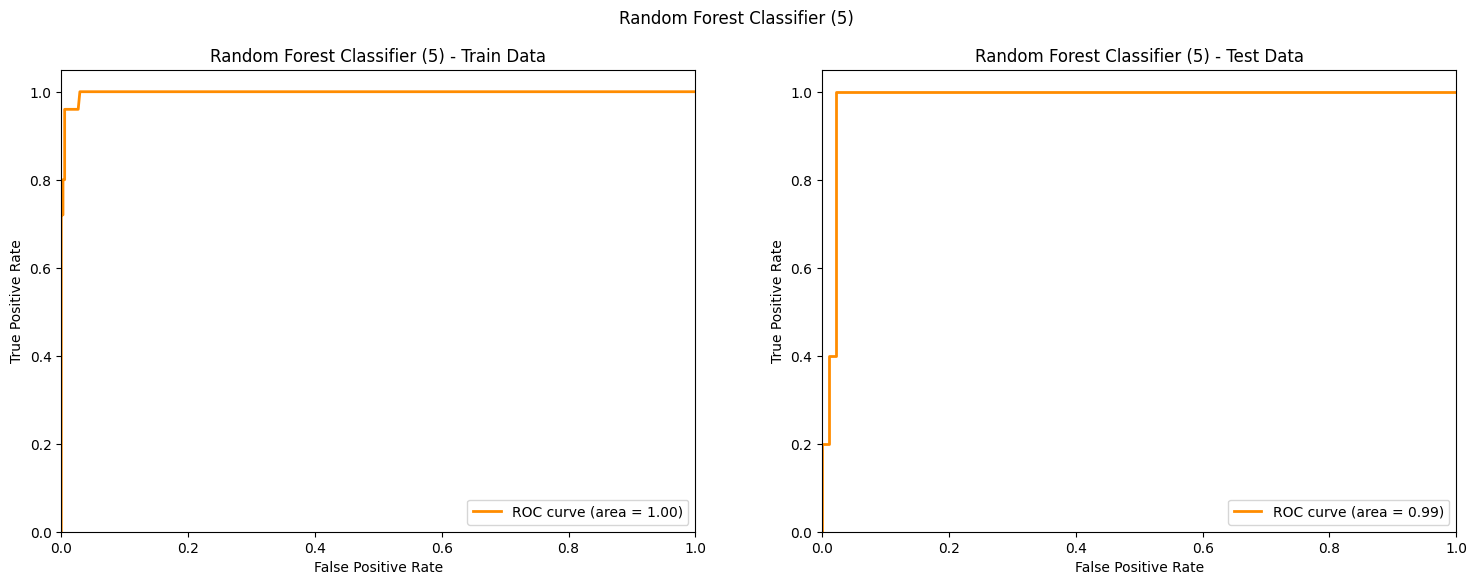

In [146]:
result = classification_model(train_set,test_set,models)

In [147]:
for res in result:
    for key, value in res.items():
        print(f"{key}: {value}")
    print('-----------------------------------')

model: Logistic Regression
dataset: train
fitted_model: LogisticRegression()
accuracy: 0.935
precision: 0.3333333333333333
recall: 0.04
f1: 0.07142857142857142
auc: 0.9082666666666666
-----------------------------------
model: Logistic Regression
dataset: test
accuracy: 0.95
precision: 0.0
recall: 0.0
f1: 0.0
auc: 0.9452631578947368
-----------------------------------
model: SVC (linear)
dataset: train
fitted_model: SVC(kernel='linear', probability=True)
accuracy: 0.935
precision: 0.0
recall: 0.0
f1: 0.0
auc: 0.9005866666666666
-----------------------------------
model: SVC (linear)
dataset: test
accuracy: 0.95
precision: 0.0
recall: 0.0
f1: 0.0
auc: 0.9410526315789473
-----------------------------------
model: Random Forest Classifier (1)
dataset: train
fitted_model: RandomForestClassifier()
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0
auc: 1.0
-----------------------------------
model: Random Forest Classifier (1)
dataset: test
accuracy: 0.96
precision: 0.6666666666666666
recall:

Based on the Test Dataset Performance , **Random Forest Classifier with min_sample_leaf = 3** performs the best overall, with highest accuracy, precision, recall and F-1 score and a very high AUC. 

Close Alternative is :
Random Forest Classifier with min_sample_leaf = 5 


## Other Cities Customer Data Prediction

For customers from other cities, we aim to achieve two main objectives using machine learning models:

1. **Regression Model**:
   - **Objective**: Predict the total sales value of a product based on its selling price.
   - **Approach**: Use regression techniques to model the relationship between the selling price and the total sales value.
   - **Potential Models**: Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, etc.

2. **Classification Model**:
   - **Objective**: Classify the product based on the likelihood of it being returned.
   - **Approach**: Use classification techniques to predict whether a product will be returned or not.
   - **Potential Models**: Logistic Regression, Support Vector Classifier (SVC), Random Forest Classifier, Gradient Boosting Classifier, etc.

Let's take a look at Dataset once again

<Axes: xlabel='SellingPrice', ylabel='Sales'>

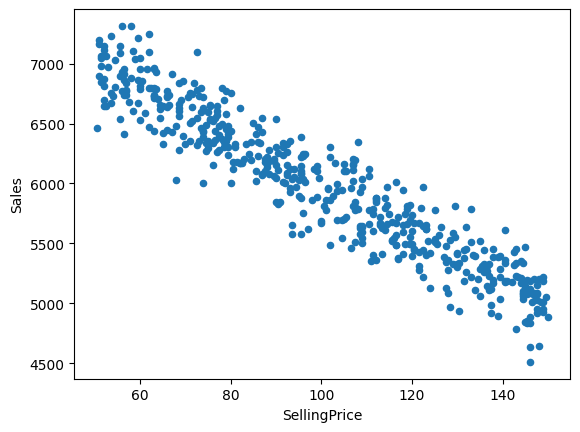

In [148]:
other_Dataset.plot(kind='scatter', x='SellingPrice', y='Sales')

<Axes: xlabel='SellingPrice', ylabel='Sales'>

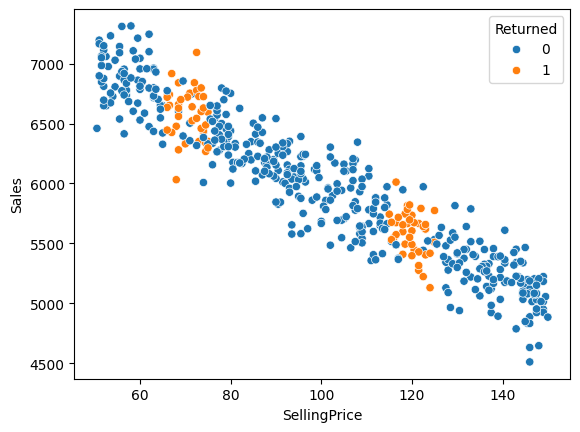

In [149]:
sns.scatterplot(data=other_Dataset, x='SellingPrice', y='Sales',hue='Returned')

### Regression Analysis of Other cities customers 

In [150]:
train_set, test_set = train_test_split(other_Dataset, test_size=0.2, random_state=0)

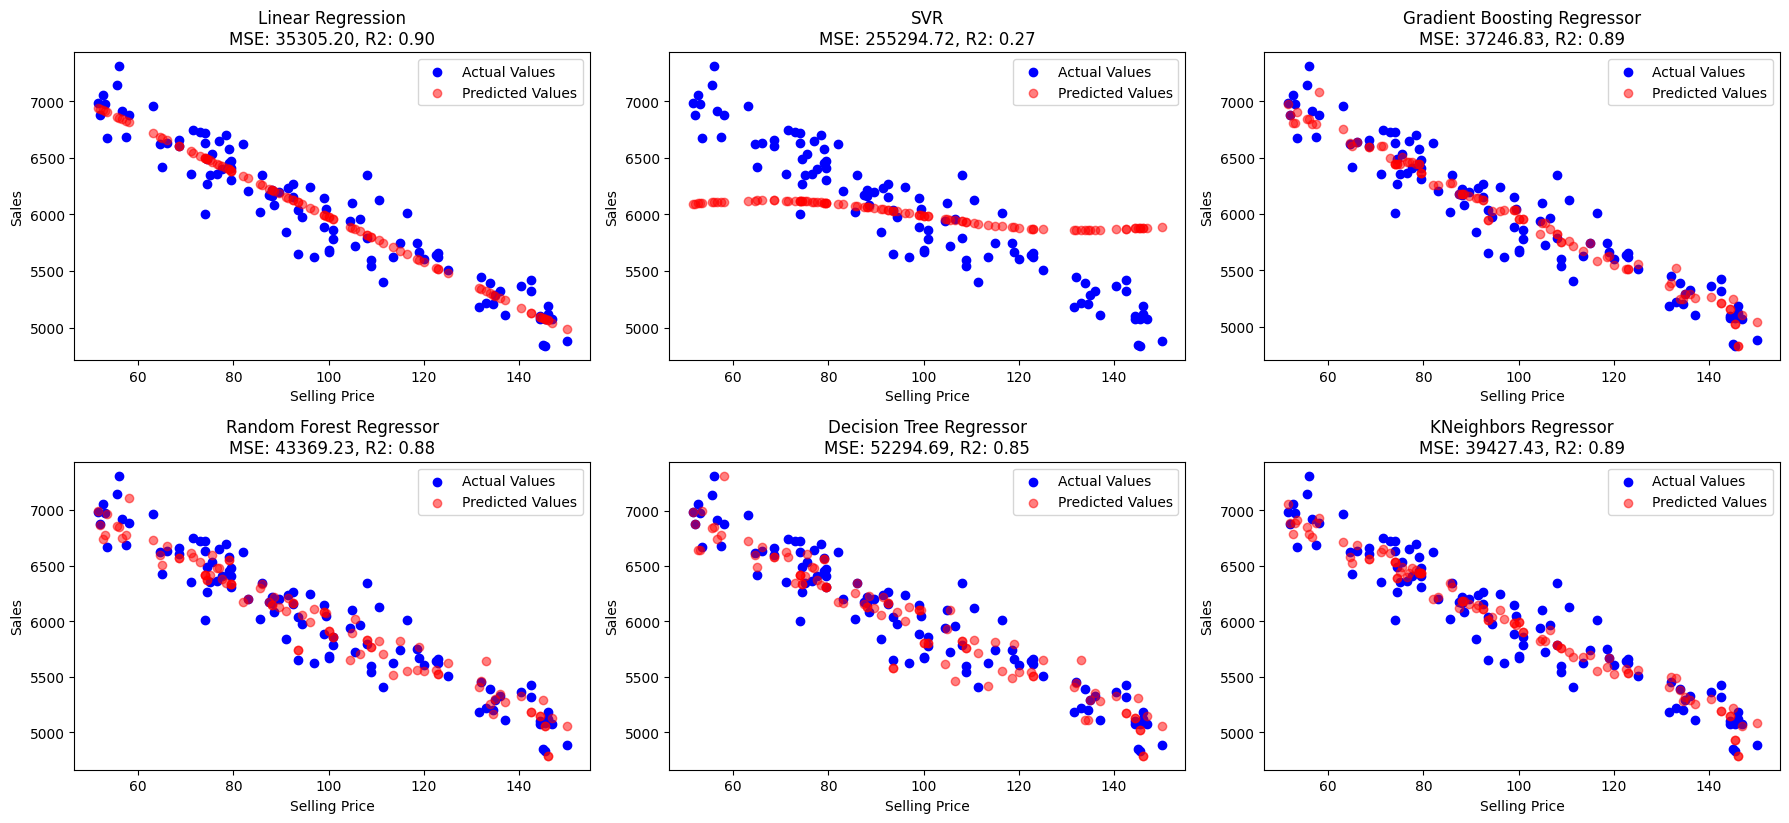

Linear Regression:
MSE: 175301.64179862247
R2: 0.2496541229023186

SVR:
MSE: 215487.95334197447
R2: 0.07764413558596428

Gradient Boosting Regressor:
MSE: 40177.0060355116
R2: 0.8280298431688067

Random Forest Regressor:
MSE: 44723.65403165435
R2: 0.8085687671428379

Decision Tree Regressor:
MSE: 45569.13538948398
R2: 0.8049498423883328

KNeighbors Regressor:
MSE: 46891.033699999985
R2: 0.7992917040100425



In [151]:
regression_results_other_cities = perform_regression(train_set, test_set)

for model, metrics in regression_results.items():
    print(f"{model}:")
    print(f"MSE: {metrics['MSE']}")
    print(f"R2: {metrics['R2']}")
    print()

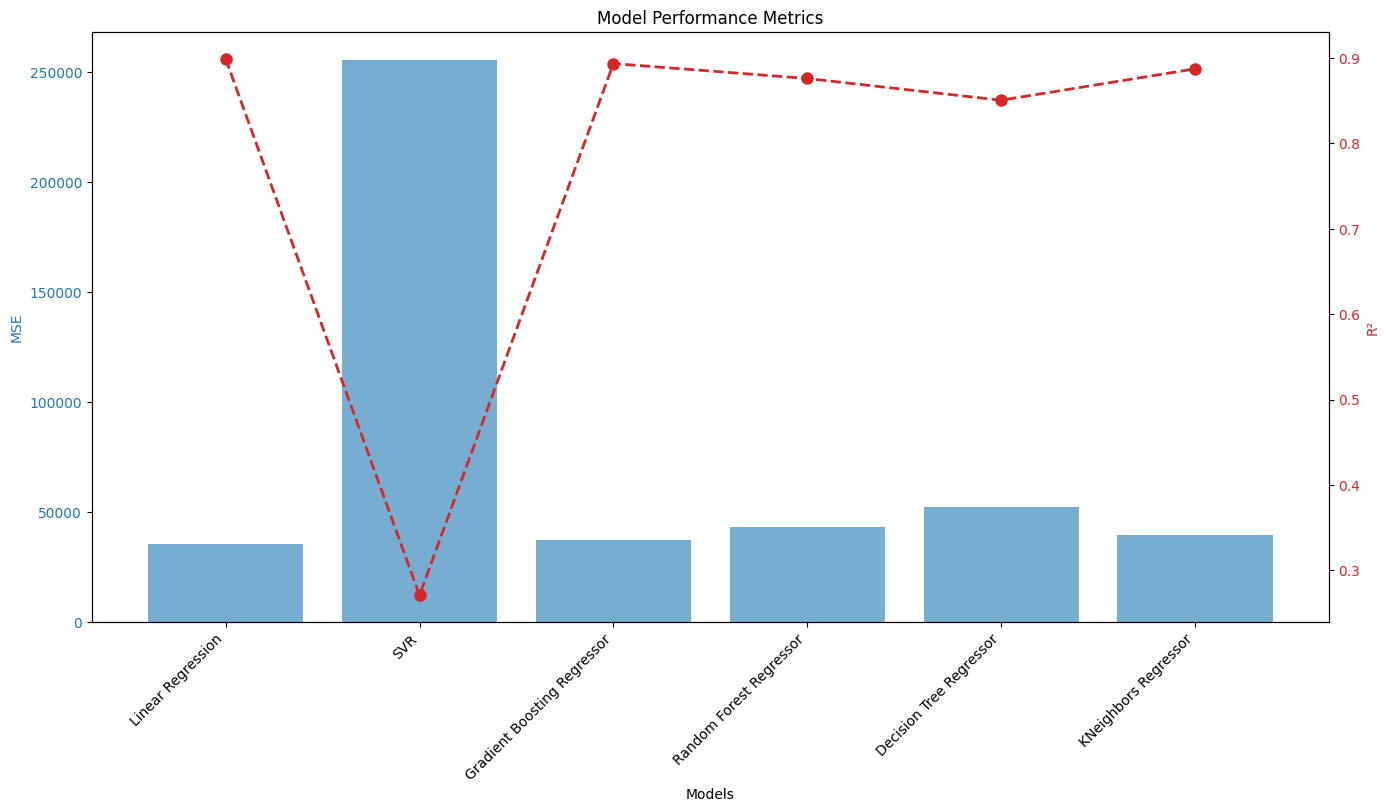

In [152]:
plot_metrics(regression_results_other_cities)

**Gradient Boosting Regressor** performs the best among the models listed with lowest MSE and highest R^2

Decision Tree Regressor can be a closed alternative

### Classification Prediction

Classification Models to examine are : 
- Logistic Regression
- SVC
- Random Forest Classifier ( three types with min_leaf_sample as 1,3 and 5)

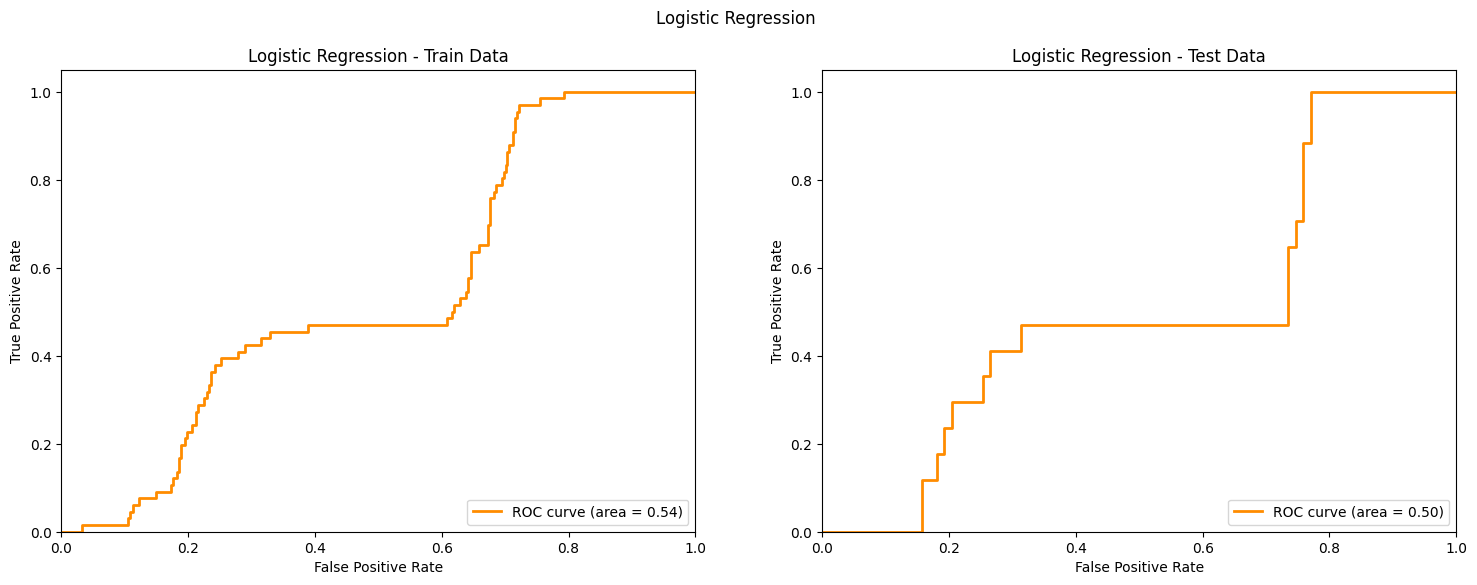

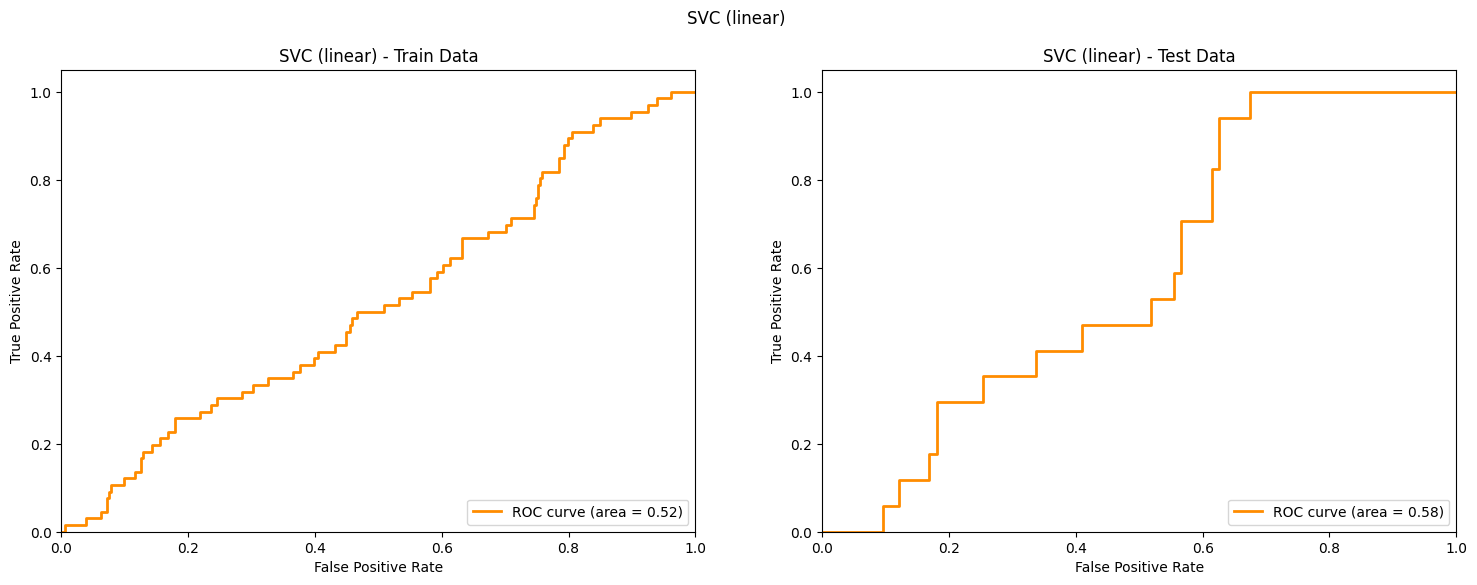

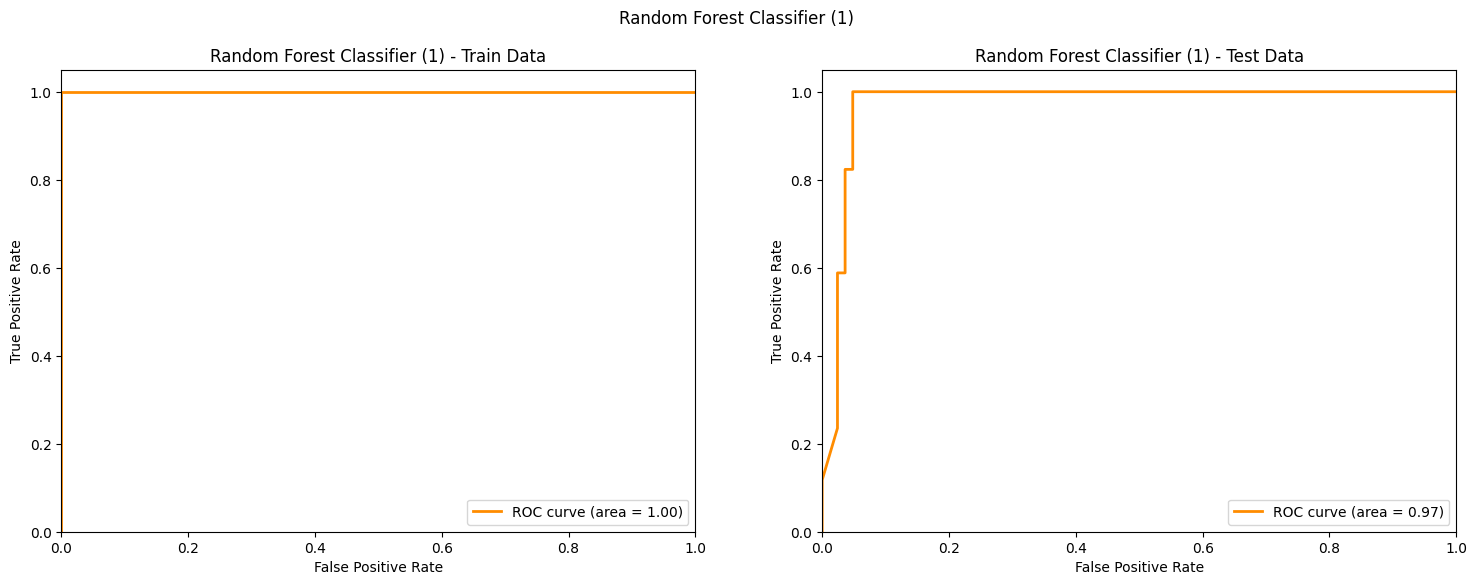

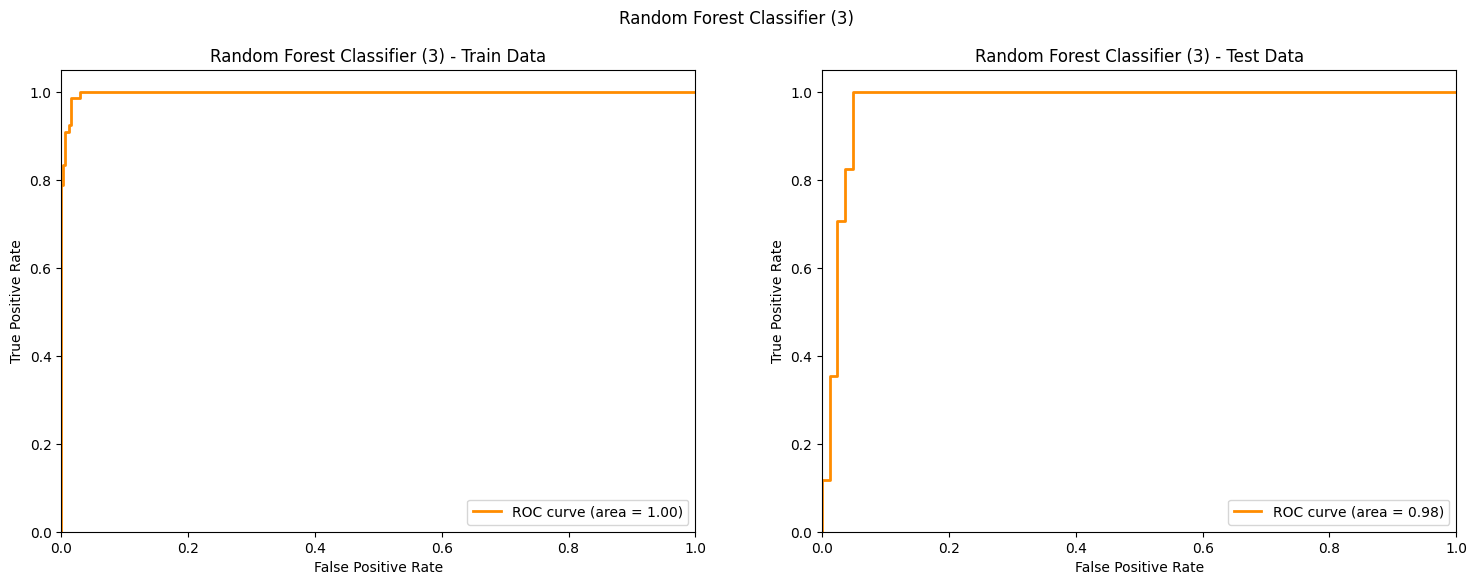

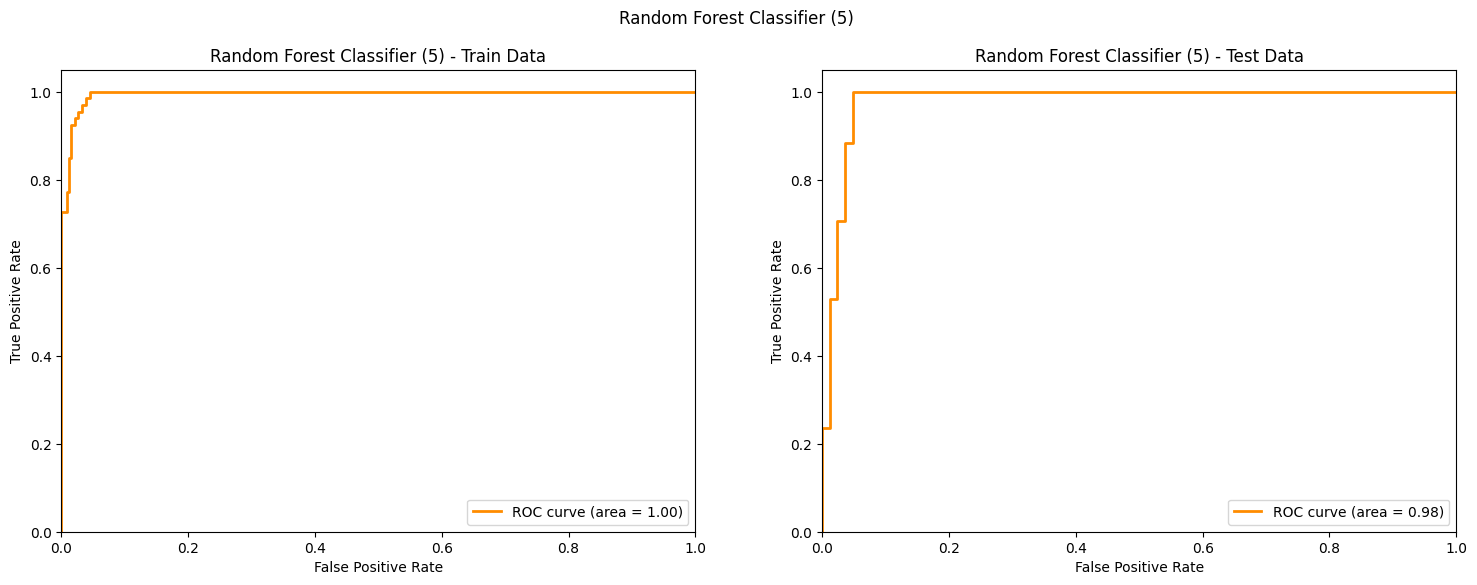

In [153]:
other_cities_classification_result = classification_model(train_set, test_set, models)

In [154]:
for res in other_cities_classification_result:
    for key, value in res.items():
        print(f"{key}: {value}")
    print('-----------------------------------')

model: Logistic Regression
dataset: train
fitted_model: LogisticRegression()
accuracy: 0.835
precision: 0.0
recall: 0.0
f1: 0.0
auc: 0.5425058972963165
-----------------------------------
model: Logistic Regression
dataset: test
accuracy: 0.83
precision: 0.0
recall: 0.0
f1: 0.0
auc: 0.5003543586109143
-----------------------------------
model: SVC (linear)
dataset: train
fitted_model: SVC(kernel='linear', probability=True)
accuracy: 0.835
precision: 0.0
recall: 0.0
f1: 0.0
auc: 0.5201868989294138
-----------------------------------
model: SVC (linear)
dataset: test
accuracy: 0.83
precision: 0.0
recall: 0.0
f1: 0.0
auc: 0.5818568391211907
-----------------------------------
model: Random Forest Classifier (1)
dataset: train
fitted_model: RandomForestClassifier()
accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0
auc: 1.0
-----------------------------------
model: Random Forest Classifier (1)
dataset: test
accuracy: 0.93
precision: 0.8125
recall: 0.7647058823529411
f1: 0.7878787878787878
a

**Random Forest Classifier (1)** performs the best overall, with the highest accuracy, precision, recall, F1 score, and AUC.

Close Alternative can be Random Forest Classifier (3) or (5)

## Observations

### For Class-A Cities Customers

1. **Best Model to Predict Total Sales**:
   - **Model**: Gradient Boosting Regressor
   - **Reason**: The Gradient Boosting Regressor outperformed other models in terms of accuracy and generalization. It effectively captures the complex relationships between the selling price and total sales, making it the most suitable model for predicting total sales in Class-A cities.

2. **Best Model to Classify Returned Products**:
   - **Model**: Random Forest Classifier with `min_samples_leaf = 3`
   - **Reason**: The Random Forest Classifier with a minimum of 3 samples per leaf node provided the best balance between precision and recall. This configuration helps in reducing overfitting and ensures that the model generalizes well to new data, making it the best choice for classifying returned products in Class-A cities.

### For Other Cities Customers

1. **Best Model to Predict Total Sales**:
   - **Model**: Gradient Boosting Regressor
   - **Reason**: Similar to Class-A cities, the Gradient Boosting Regressor demonstrated superior performance in predicting total sales for customers from other cities. Its ability to handle non-linear relationships and interactions between features makes it the best model for this task.

2. **Best Model to Classify Returned Products**:
   - **Model**: Random Forest Classifier with `min_samples_leaf = 1`
   - **Reason**: For customers from other cities, the Random Forest Classifier with a minimum of 1 sample per leaf node provided the highest accuracy and F1 score. This configuration allows the model to capture more detailed patterns in the data, making it the most effective model for classifying returned products in this segment.

### Summary

- **Gradient Boosting Regressor** is the best model for predicting total sales for both Class-A cities and other cities customers.
- **Random Forest Classifier** with different `min_samples_leaf` settings is the best model for classifying returned products:
  - `min_samples_leaf = 3` for Class-A cities customers.
  - `min_samples_leaf = 1` for other cities customers.

These observations highlight the importance of selecting the appropriate model and configuration based on the specific characteristics of the customer segment.

# Predictive Plots
 Creating a predictive plot using developed models for Selling Price Ranging between Rs.60 and Rs.150

In [155]:
# Create a dataset with Selling Price ranging from Rs. 60 to Rs. 150 incremented by 5
selling_price_range = np.arange(60, 155, 5)
predictive_dataset = pd.DataFrame({'SellingPrice': selling_price_range})

print(predictive_dataset)

    SellingPrice
0             60
1             65
2             70
3             75
4             80
5             85
6             90
7             95
8            100
9            105
10           110
11           115
12           120
13           125
14           130
15           135
16           140
17           145
18           150


### For Class A cities customers

In [165]:
classA_prediction_Dataset = predictive_dataset.copy()
classA_prediction_Dataset['Sales'] = regression_results['Gradient Boosting Regressor']['model'].predict(predictive_dataset)

<Axes: xlabel='SellingPrice', ylabel='Sales'>

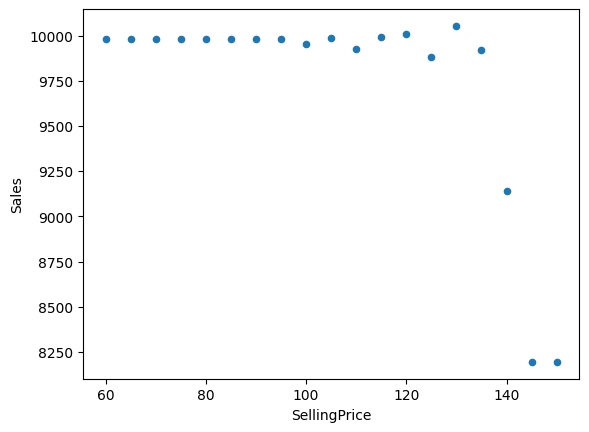

In [166]:
classA_prediction_Dataset.plot(kind='scatter', x='SellingPrice', y='Sales')

In [167]:
classA_prediction_Dataset['Returned'] = result[6]['fitted_model'].predict(classA_prediction_Dataset[['SellingPrice', 'Sales']])

<Axes: xlabel='SellingPrice', ylabel='Sales'>

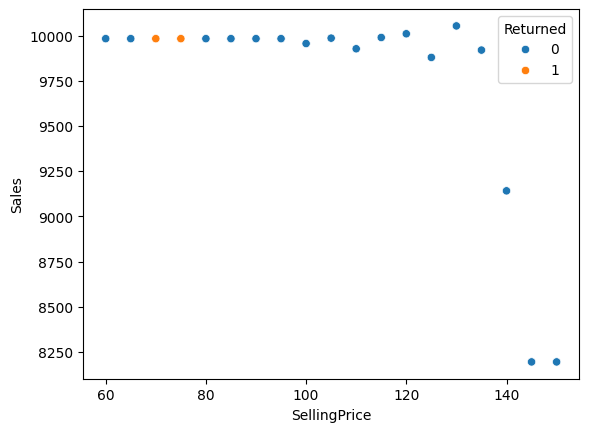

In [168]:
sns.scatterplot(data=classA_prediction_Dataset, x='SellingPrice', y='Sales',hue='Returned')

In [174]:
classA_prediction_Dataset.to_csv('classA_prediction_Dataset.csv', index=False)

### For Other Cities Customers

In [169]:
other_prediction_Dataset = predictive_dataset.copy()
other_prediction_Dataset['Sales'] = regression_results_other_cities['Gradient Boosting Regressor']['model'].predict(predictive_dataset)

<Axes: xlabel='SellingPrice', ylabel='Sales'>

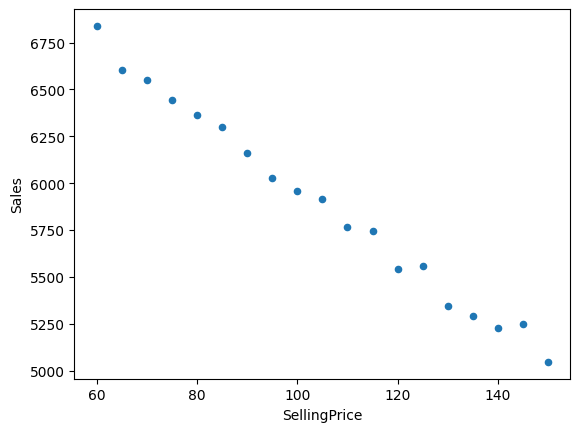

In [170]:
other_prediction_Dataset.plot(kind='scatter', x='SellingPrice', y='Sales')

In [171]:
other_prediction_Dataset['Returned'] = other_cities_classification_result[4]['fitted_model'].predict(other_prediction_Dataset[['SellingPrice', 'Sales']])

<Axes: xlabel='SellingPrice', ylabel='Sales'>

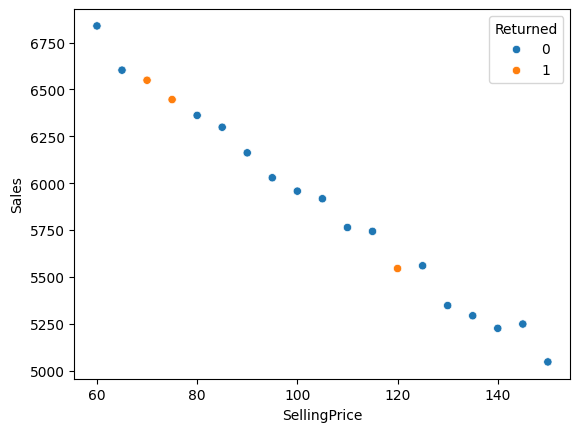

In [172]:
sns.scatterplot(data=other_prediction_Dataset, x='SellingPrice', y='Sales',hue='Returned')

In [175]:
other_prediction_Dataset.to_csv('other_prediction_Dataset.csv',index=False)